<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 3 — Overfitting, Regularización y SVM</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

Se te proporcionan dos datasets biomédicos independientes:

1. **EMG Gesture Classification** — features estadísticas de electromiografía de superficie (sEMG) registradas durante dos gestos activos de la mano. El dataset original tiene 3 clases (0=reposo, 1=pulgar abajo, 2=pulgar arriba); trabajaremos solo con **clases 1 y 2** — el problema clínicamente relevante: **¿el usuario intenta cerrar o abrir la mano?** Contexto: **control de prótesis mioeléctrica**.
2. **Brain Tumor MRI** — imágenes de resonancia magnética cerebral: **Tumor vs No tumor**. Pipeline: flatten → PCA → SVM.

---

### Datasets necesarios

| Datos | Fuente | Extensión |
|---|---|---|
| EMG Gesture Classification | [Kaggle](https://www.kaggle.com/datasets/birdy654/emg-gesture-classification-thumbs-up-and-down) | `.csv` |
| Brain Tumor MRI | [Kaggle](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset) | `.jpg` |

```
Clase4_Challenge/
├── Challenge3_ApellidoNombre.ipynb
├── emg_gestures.csv
└── brain_tumor/
    ├── Training/
    │   ├── notumor/
    │   └── tumor/   (glioma + meningioma + pituitary)
    └── Testing/
        ├── notumor/
        └── tumor/
```


<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>


---
## Ejercicio 1 — Diseño previo al código (conceptual)

> **Antes de escribir una línea de código**, razona sobre el problema.

### 1.1 — Diagnóstico esperado

Responde antes de ver los datos:

1. La señal EMG de un músculo tiene patrones de amplitud y frecuencia distintos según el gesto. ¿Esperas que SVM Lineal o RBF funcione mejor para clasificar pulgar abajo vs pulgar arriba? ¿Por qué?
2. ¿Por qué es necesario PCA antes de SVM en imágenes MRI? ¿Qué pasaría si aplicaras SVM directamente sobre los 22 500 píxeles?
3. En una prótesis mioeléctrica, ¿qué error es más problemático: clasificar mal el gesto (FP) o no detectarlo (FN)? ¿Cambia la respuesta si lo comparas con el diagnóstico de tumor cerebral?

**📝 Tu respuesta (edita esta celda):**
1. Se espera que el SVM con kernel RBF (gaussiano) funcione mejor para clasificar pulgar abajo vs pulgar arriba. Esto se debe a que las señales EMG presentan relaciones complejas en amplitud y frecuencia, así como interacciones no lineales entre variables (por ejemplo, entre distintos canales o componentes en frecuencia).<br><br>
En este tipo de datos, las clases no suelen ser separables mediante un hiperplano lineal en el espacio original. <br>El kernel RBF permite proyectar los datos a un espacio de mayor dimensión donde sí es posible encontrar una frontera de decisión lineal, que en el espacio original se traduce en una frontera no lineal. <br><br>
Gracias al kernel trick, esta transformación no se calcula explícitamente, lo que hace viable modelar patrones complejos. En cambio, un SVM lineal solo es adecuado cuando la separación entre clases es aproximadamente lineal, lo cual rara vez ocurre en señales biomédicas como EMG.

2. El uso de PCA es fundamental en imágenes MRI debido a su altísima dimensionalidad (por ejemplo, 22 500 píxeles por imagen). Aplicar SVM directamente sobre todos los píxeles implicaría varios problemas: <br><br>
- Sobreajuste (overfitting): el modelo tendría demasiadas variables en relación con el número de muestras, lo que reduce su capacidad de generalización.<br><br>
- Alta complejidad computacional: tanto el entrenamiento como la predicción serían mucho más lentos.<br><br>
- Redundancia y ruido: muchos píxeles contienen información repetida o irrelevante, lo que puede degradar el rendimiento del modelo.<br><br>PCA reduce la dimensionalidad proyectando los datos en un nuevo espacio de menor dimensión que conserva la mayor varianza posible. Esto permite eliminar ruido, reducir redundancia y facilitar el aprendizaje del SVM. Sin PCA, el SVM podría volverse inestable, lento y propenso a sobreajustarse.

3. En una prótesis mioeléctrica, el error más problemático es el falso positivo (FP), es decir, detectar un gesto que el usuario no realizó. Este tipo de error implica que el sistema ejecuta una acción incorrecta, lo que puede generar movimientos involuntarios, afectar la precisión del control e incluso representar un riesgo físico para el usuario. Dado que la interacción es directa y en tiempo real, la seguridad y la confiabilidad son críticas. Por ello, en este contexto es preferible un falso negativo (FN), donde el sistema no responde, antes que provocar una acción equivocada.<br><br>
En contraste, en el diagnóstico de tumor cerebral, el error más crítico es el falso negativo (FN), ya que implica no detectar la presencia de un tumor existente. Este tipo de fallo puede retrasar el diagnóstico, limitar las opciones de tratamiento y comprometer seriamente la salud del paciente. En este escenario, es más aceptable incurrir en falsos positivos (FP), ya que estos pueden ser posteriormente evaluados y descartados mediante pruebas adicionales. Por tanto, mientras en sistemas de control como prótesis se prioriza evitar acciones incorrectas, en aplicaciones médicas diagnósticas se prioriza no omitir casos reales, incluso a costa de generar algunas alertas innecesarias.


### 1.2 — Pipeline completo

Completa el pipeline para cada dataset:

```
emg_gestures.csv
    │
    ▼
[ Paso A ] Filtrado de clases (1 y 2) + recodificación (0/1) + EDA  ← ¿Qué haces primero? (antes del split) → Se limpia y
prepara el dataset (selección de clases y codificación) y se realiza un análisis exploratorio para entender la distribución
de los datos antes de modelar.
    │
    ▼
[ Paso B ] Train/Test split (80/20, estratificado) ← ¿Cuándo haces el split? ¿Por qué aquí? → Se realiza después del
preprocesamiento inicial para separar los datos en entrenamiento y prueba,evitando data leakage y asegurando que el
test represente datos no vistos.
    │
    ▼
[ Paso C ] Escalamiento con StandardScaler (fit en train, transform en train y test) ← ¿Qué preprocesamiento? ¿Con qué
datos? → Se normalizan las variables para SVM. El scaler se ajusta solo con datos de entrenamiento y luego se aplica a
train y test para evitar contaminación de información.
    │
    ▼
[ Paso D ] Selección de hiperparámetro C con validación cruzada   ← ¿Cómo eliges C sin tocar el test? → Se usa cross-validation
sobre el conjunto de entrenamiento para evaluar distintos valores de C y seleccionar el óptimo sin utilizar el conjunto de
prueba.
    │
    ▼
[ Paso E ] Evaluación final en test (accuracy, matriz de confusión, métricas)  ← ¿Cuándo y cómo evalúas en test? → Se evalúa una
única vez con el modelo final ya entrenado, utilizando métricas como accuracy,precision, recall y F1, para medir la capacidad de
generalización.

Brain Tumor MRI
    │
    ▼
[ Paso A ] flatten + StandardScaler (fit en train) → Se convierte la imagen 2D en un vector y se normalizan las intensidades.
El scaler se ajusta solo con datos de entrenamiento para evitar data leakage.
    │
    ▼
[ Paso B ] PCA (ajustado solo en train)  ← ¿Por qué PCA aquí y no antes del split? → PCA aprende una representación de los
datos; si se ajusta antes del split, se filtra información del test (data leakage). Por eso se ajusta solo en train.
    │
    ▼
[ Paso C ] SVM con kernel RBF + selección de C con validación cruzada (CV-5)
```

**📝 Tu respuesta (edita esta celda):**
- EMG: ___
- MRI: ___


In [ ]:
# ── Conexión con Google Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


---
## Ejercicio 2 — Setup


In [ ]:
UPCH_RED   = '#8B0000'
UPCH_BLUE  = '#1565C0'
UPCH_GREEN = '#2E7D32'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (train_test_split, learning_curve,
                                      StratifiedKFold, cross_val_score)
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              recall_score, precision_score, f1_score)

plt.rcParams['figure.dpi'] = 120
BASE = Path('/content/drive/MyDrive/ColabNotebooks/ReconocimientoDePatrones/2026_1/Clase2')
print('Setup completo ✓')


Setup completo ✓


---
# PARTE 1 — Señal EMG: Control de Prótesis Mioeléctrica

## Ejercicio 3 — Carga, filtrado y EDA

El dataset contiene features estadísticas de sEMG con 3 clases originales:

| Clase | Gesto | Aplicación |
|---|---|---|
| 0 | Reposo (relax) | Estado neutro |
| 1 | Pulgar abajo | Apertura de mano |
| 2 | Pulgar arriba | Cierre de mano |

> Trabajamos con **clases 1 y 2** — el problema activo de la prótesis: ¿abrir o cerrar la mano?

### Paso 3.1 — Carga, inspección y filtrado


In [ ]:
df_raw = pd.read_csv(BASE / 'thumbs.csv')

print(f'Shape original: {df_raw.shape}')
print(f'\nDistribucion original de clases:')
TARGET = df_raw.columns[-1]
print(df_raw[TARGET].value_counts().sort_index())
df_raw.head()


Shape original: (3173, 2041)

Distribucion original de clases:
Label
0.0     965
1.0    1118
2.0    1090
Name: count, dtype: int64


,lag1_mean_0,lag1_mean_1,lag1_mean_2,lag1_mean_3,lag1_mean_4,lag1_mean_5,lag1_mean_6,lag1_mean_7,lag1_mean_d_h2h1_0,lag1_mean_d_h2h1_1,...,freq_669_7,freq_679_7,freq_689_7,freq_699_7,freq_709_7,freq_720_7,freq_730_7,freq_740_7,freq_750_7,Label
0,-1.040000,-1.140000,-1.250000,-1.115000,-1.195000,-1.13000,-0.955000,-0.870000,-0.028839,-0.001432,...,0.021704,0.090170,0.054362,0.103776,0.045830,0.121577,0.040301,0.150245,0.106731,0.0
1,-1.050251,-1.040201,-1.110553,-3.713568,-0.693467,-0.81407,-1.095477,-1.030151,0.054493,0.400520,...,0.001214,0.001994,0.000601,0.002327,0.000819,0.001045,0.000895,0.001753,0.000857,0.0
2,-1.055000,-1.110000,-1.090000,-1.085000,-1.055000,-1.08500,-0.995000,-1.185000,1.613818,-0.138514,...,0.108152,0.095529,0.044617,0.105610,0.036643,0.071162,0.056146,0.079932,0.059948,2.0
3,-1.185000,-1.095000,-1.205000,-1.025000,-1.085000,-1.03500,-1.125000,-0.800000,0.518470,0.161348,...,0.065420,0.087290,0.063137,0.056442,0.112511,0.040761,0.087850,0.035891,0.210210,1.0
4,-1.135000,-1.235000,-1.150000,-1.030000,-1.105000,-1.16500,-1.175000,-1.115000,0.228686,0.274966,...,0.011784,0.068165,0.186553,0.064211,0.051568,0.036873,0.049948,0.061788,0.122097,1.0


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: filtra el dataframe conservando SOLO las filas donde TARGET == 1 o TARGET == 2
# Pista: usa isin()
df = df_raw[df_raw[TARGET].isin([1.0, 2.0])]

# Recodificar: clase 1 → 0 (pulgar abajo), clase 2 → 1 (pulgar arriba)
# Esto convierte el problema a binario 0/1 para SVM
df = df.copy()
df[TARGET] = df[TARGET].map({1.0: 0, 2.0: 1})

print(f'Shape tras filtrado: {df.shape}')
print(f'\nClases tras recodificacion:')
print(df[TARGET].value_counts().sort_index())
print('  0 = Pulgar abajo  |  1 = Pulgar arriba')


Shape tras filtrado: (2208, 2041)

Clases tras recodificacion:
Label
0    1118
1    1090
Name: count, dtype: int64
  0 = Pulgar abajo  |  1 = Pulgar arriba


### Paso 3.2 — EDA: distribución de features por gesto
> ¿Qué features tienen distribuciones más distintas entre pulgar abajo y arriba? Esas serán las más discriminativas para SVM.


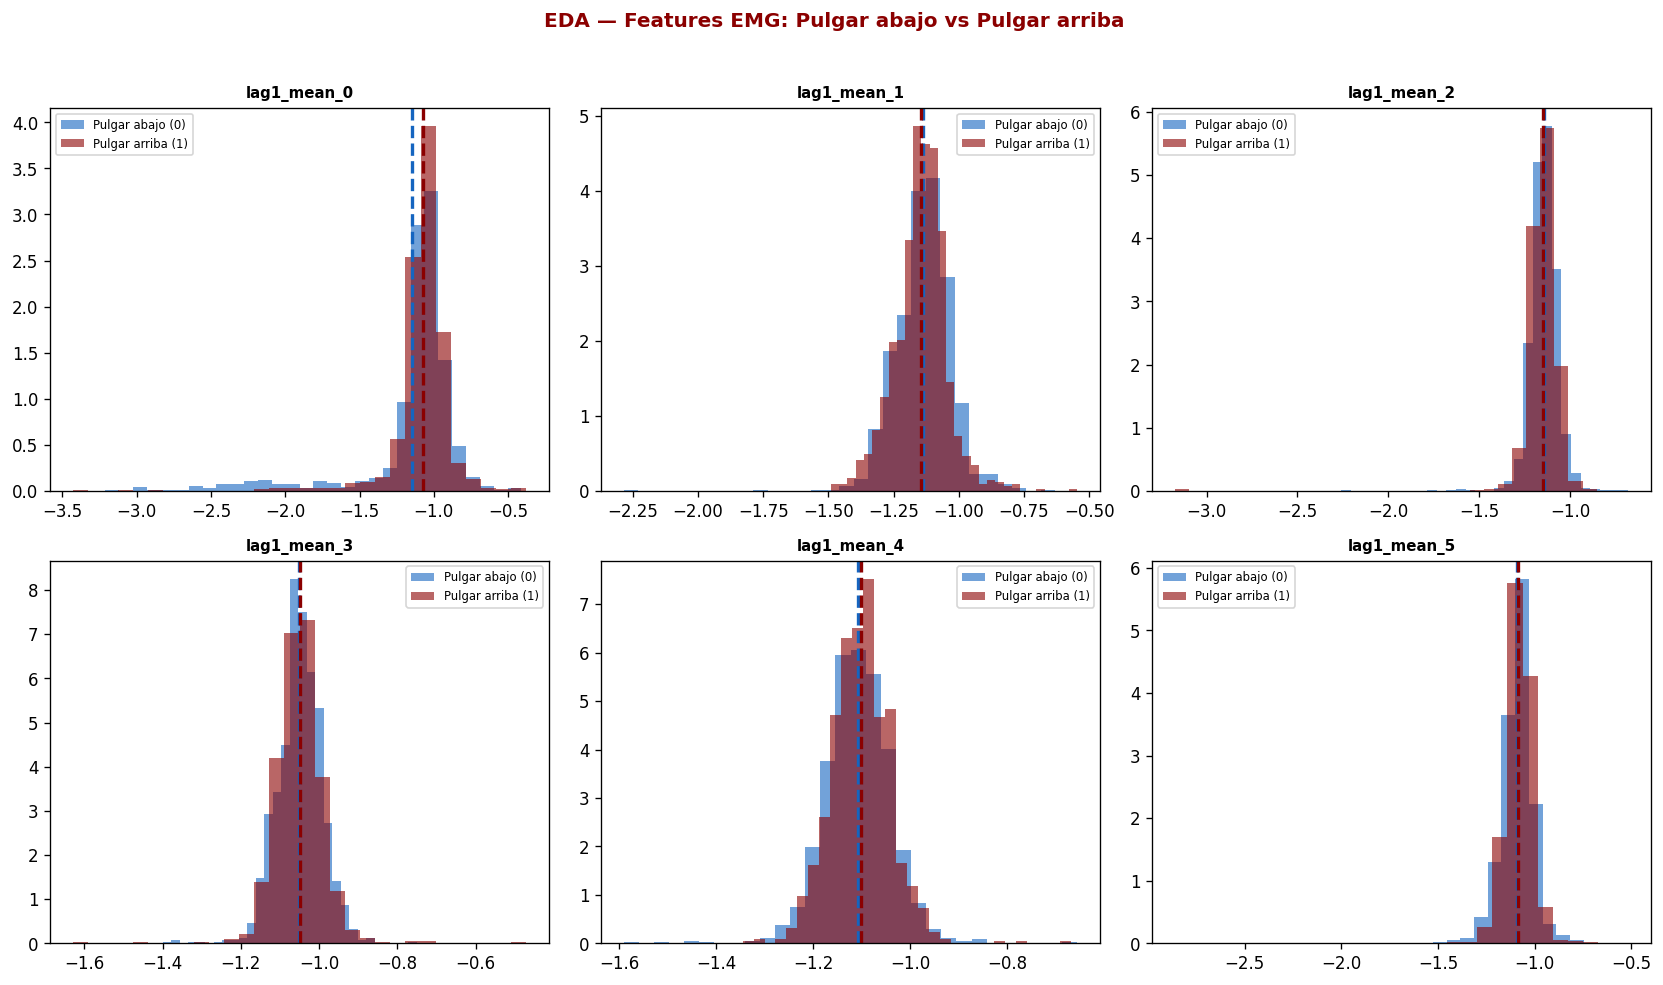

In [ ]:
features_num = df.drop(columns=[TARGET]).columns[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(features_num):
    ax = axes[i]
    # --- COMPLETA EL CÓDIGO ---
    # TODO: grafica histogramas superpuestos por clase (density=True, alpha=0.6)
    # UPCH_BLUE para clase 0 (pulgar abajo), UPCH_RED para clase 1 (pulgar arriba)
    # Agrega líneas verticales con la media de cada clase
    for clase, color, label in [(0, UPCH_BLUE, 'Pulgar abajo (0)'),
                                  (1, UPCH_RED,  'Pulgar arriba (1)')]:
        vals = df[df[TARGET] == clase][feat]
        ax.hist(vals, bins=30, density=True, alpha=0.6,
                color=color, label=label)
        ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=2)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle('EDA — Features EMG: Pulgar abajo vs Pulgar arriba',
             fontsize=12, fontweight='bold', color=UPCH_RED, y=1.02)
plt.tight_layout()
plt.savefig('eda_emg.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Ejercicio 4 — Preprocesamiento EMG

### Paso 4.1 — Split estratificado y escalado z-score

> **Regla:** separar primero, preprocesar después. El `StandardScaler` se ajusta **solo sobre train**.


In [ ]:
X_raw = df.drop(columns=[TARGET]).values
y_raw = df[TARGET].values.astype(int)   # 0 = pulgar abajo, 1 = pulgar arriba

# --- COMPLETA EL CÓDIGO ---
# TODO 1: split 80/20 estratificado, random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42
)

# TODO 2: StandardScaler — fit SOLO sobre train
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape}  '
      f'Pulgar abajo: {(y_train==0).sum()}  Pulgar arriba: {(y_train==1).sum()}')
print(f'Test:  {X_test_sc.shape}   '
      f'Pulgar abajo: {(y_test==0).sum()}   Pulgar arriba: {(y_test==1).sum()}')
print(f'\nTrain escalado — mean~{X_train_sc.mean():.4f}  std~{X_train_sc.std():.4f}')


Train: (1766, 2040)  Pulgar abajo: 894  Pulgar arriba: 872
Test:  (442, 2040)   Pulgar abajo: 224   Pulgar arriba: 218

Train escalado — mean~0.0000  std~1.0000


---
## Ejercicio 5 — Curvas de aprendizaje

### Paso 5.1 — Diagnosticar overfitting

| Patrón | Diagnóstico | Solución |
|---|---|---|
| $E_{train} \approx E_{val}$ ambos altos | Underfitting | Más capacidad |
| $E_{train} \ll E_{val}$, brecha grande | Overfitting | Regularización, más datos |
| $E_{train} \approx E_{val}$ ambos bajos | Ajuste correcto | ✓ |


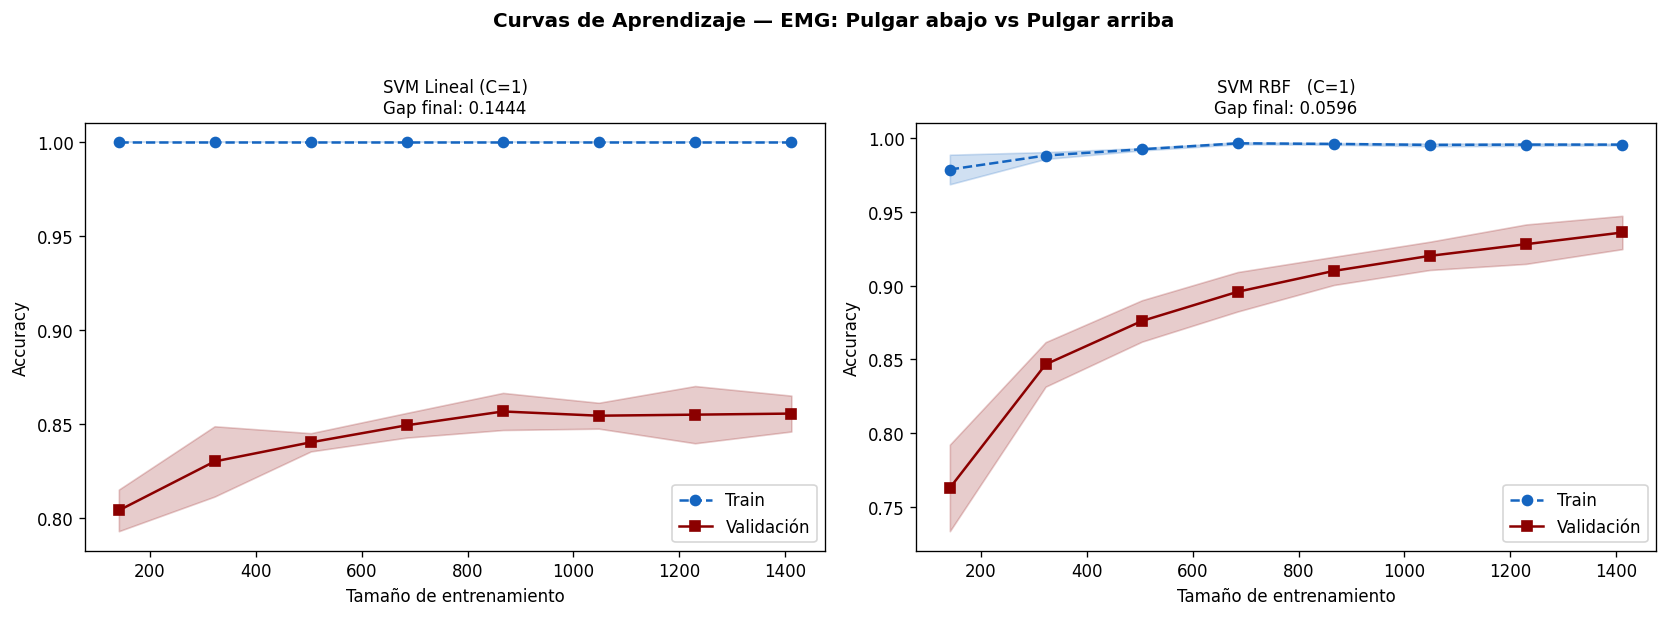

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes = np.linspace(0.1, 1.0, 8)

modelos = {
    'SVM Lineal (C=1)': SVC(kernel='linear', C=1, random_state=42),
    'SVM RBF   (C=1)':  SVC(kernel='rbf', C=1, gamma='scale', random_state=42),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (nombre, modelo) in zip(axes, modelos.items()):
    # --- COMPLETA EL CÓDIGO ---
    # TODO: usa learning_curve() con cv=cv, scoring='accuracy', n_jobs=-1
    # Grafica train (UPCH_BLUE, 'o--') y val (UPCH_RED, 's-') con banda ±1std
    # Incluye la brecha final = tr_mean[-1] - val_mean[-1] en el título
    ts, tr_sc, val_sc = learning_curve(
        modelo, X_train_sc, y_train,
        train_sizes=train_sizes,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    tr_mean = tr_sc.mean(axis=1)
    tr_std  = tr_sc.std(axis=1)
    val_mean = val_sc.mean(axis=1)
    val_std  = val_sc.std(axis=1)

    # Curva train
    ax.plot(ts, tr_mean, 'o--', color=UPCH_BLUE, label='Train')
    ax.fill_between(ts, tr_mean - tr_std, tr_mean + tr_std,
                    color=UPCH_BLUE, alpha=0.2)

    # Curva validación
    ax.plot(ts, val_mean, 's-', color=UPCH_RED, label='Validación')
    ax.fill_between(ts, val_mean - val_std, val_mean + val_std,
                    color=UPCH_RED, alpha=0.2)

    gap = tr_mean[-1] - val_mean[-1]

    ax.set_title(f'{nombre}\nGap final: {gap:.4f}', fontsize=10)
    ax.set_xlabel('Tamaño de entrenamiento')
    ax.set_ylabel('Accuracy')
    ax.legend()

plt.suptitle('Curvas de Aprendizaje — EMG: Pulgar abajo vs Pulgar arriba',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('curvas_aprendizaje_emg.png', dpi=150, bbox_inches='tight')
plt.show()


### Paso 5.2 — Interpreta las curvas

1. ¿Qué modelo tiene mayor brecha $\Delta_{gen}$? ¿Hay overfitting?
2. ¿Agregar más registros EMG mejoraría el modelo? ¿Cómo lo sabes mirando la curva?
3. ¿Qué kernel elegirías para una prótesis en tiempo real? Considera también la velocidad de predicción.

**📝 Tu respuesta:**
1. El SVM lineal presenta una mayor brecha de generalización (Δgen ≈ 0.1444) en comparación con el SVM con kernel RBF (Δgen ≈ 0.0596). Esta diferencia indica que el modelo lineal exhibe una discrepancia más pronunciada entre el desempeño en entrenamiento y en validación, lo cual es característico de un mayor grado de sobreajuste. <br><br> No obstante, en ambos modelos se observa que el rendimiento en entrenamiento es cercano al 100%, mientras que en validación es inferior, lo que sugiere la presencia de overfitting en ambos casos, aunque más acentuado en el modelo lineal.

2. Sí, particularmente en el caso del modelo con kernel RBF. Esto se evidencia en que la curva de validación continúa mostrando una tendencia ascendente a medida que aumenta el tamaño del conjunto de entrenamiento, sin haber alcanzado una meseta clara. Esto indica que el modelo aún puede mejorar su capacidad de generalización al incorporar más datos.<br><br> En contraste, en el modelo lineal la curva de validación tiende a estabilizarse, lo que sugiere que el modelo ya ha alcanzado su límite de aprendizaje dado su carácter lineal. En este contexto, agregar más datos tendría un impacto marginal, es decir, produciría mejoras muy pequeñas o casi nulas en el rendimiento, ya que la limitación principal no es la cantidad de datos sino la capacidad del modelo para representar relaciones no lineales presentes en las señales EMG.

3. Para una aplicación en tiempo real como una prótesis mioeléctrica, elegiría el SVM lineal, priorizando la eficiencia computacional y la baja latencia de predicción.<br><br> A partir de las curvas de aprendizaje, el SVM lineal alcanza un accuracy de validación aproximado de 0.85–0.86, mientras que el SVM con kernel RBF alcanza alrededor de 0.93–0.94. Si bien el modelo RBF muestra un mejor desempeño, esta diferencia debe evaluarse en conjunto con el costo computacional.<br><br> El SVM lineal presenta una complejidad de predicción de O(d), lo que permite respuestas rápidas y consistentes. En contraste, el SVM RBF depende del número de vectores de soporte (O(Nsv⋅d)), lo que incrementa el tiempo de inferencia y puede introducir latencias no deseadas en un sistema interactivo.<br><br> En este contexto, aunque el RBF ofrece una mayor precisión, el SVM lineal proporciona un mejor equilibrio entre rendimiento y velocidad. Dado que en una prótesis la respuesta inmediata es crítica para garantizar un control fluido y seguro, se prefiere un modelo más eficiente, incluso si implica una ligera reducción en accuracy.


---
## Ejercicio 6 — Selección de C con CV-5

### Paso 6.1 — Barrido de C en escala logarítmica

> **Anti-leakage:** el barrido se realiza **solo sobre train**. El test set no se toca hasta el paso final.

$$\min_{w,b,\xi} \;\frac{1}{2}\|w\|^2 + C\sum_{i=1}^{n}\xi_i$$


In [ ]:
C_values = [0.001, 0.01, 0.1, 1, 10]
acc_lineal, acc_rbf = [], []

# Suponiendo que 'cv' ya está definido (ej. cv = 5 o un objeto KFold)
# Y que X_train_sc y y_train están listos

for C in C_values:
    # 1. Definir los modelos
    svm_lin = SVC(kernel='linear', C=C, random_state=42)
    svm_rbf = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)

    # 2. Calcular validación cruzada (promedio de los 5 folds)
    sc_lin = cross_val_score(svm_lin, X_train_sc, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()
    sc_rbf = cross_val_score(svm_rbf, X_train_sc, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()

    # 3. Guardar resultados
    acc_lineal.append(sc_lin)
    acc_rbf.append(sc_rbf)

    # 4. Imprimir progreso
    print(f'C={C:>6} | Lineal Accuracy: {sc_lin:.4f} | RBF Accuracy: {sc_rbf:.4f}')

# IDENTIFICACIÓN DE PARÁMETROS ÓPTIMOS

C_opt_lin = C_values[np.argmax(acc_lineal)]
C_opt_rbf = C_values[np.argmax(acc_rbf)]

print("-" * 50)
print(f'C óptimo Lineal: {C_opt_lin} (Acc = {max(acc_lineal):.4f})')
print(f'C óptimo RBF:    {C_opt_rbf} (Acc = {max(acc_rbf):.4f})')


C= 0.001 | Lineal Accuracy: 0.8901 | RBF Accuracy: 0.5062
C=  0.01 | Lineal Accuracy: 0.8562 | RBF Accuracy: 0.5062
C=   0.1 | Lineal Accuracy: 0.8562 | RBF Accuracy: 0.7389
C=     1 | Lineal Accuracy: 0.8562 | RBF Accuracy: 0.9360
C=    10 | Lineal Accuracy: 0.8562 | RBF Accuracy: 0.9485
--------------------------------------------------
C óptimo Lineal: 0.001 (Acc = 0.8901)
C óptimo RBF:    10 (Acc = 0.9485)


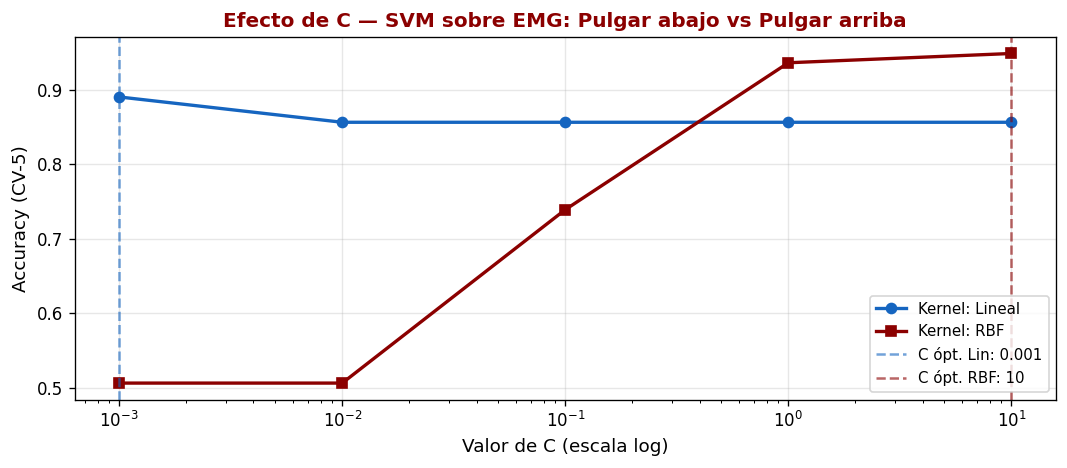

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

# 1. Graficar las curvas de Accuracy (usamos semilogx para el eje X logarítmico)
ax.semilogx(C_values, acc_lineal, marker='o', label='Kernel: Lineal', color=UPCH_BLUE, lw=2)
ax.semilogx(C_values, acc_rbf, marker='s', label='Kernel: RBF', color=UPCH_RED, lw=2)

# 2. Incluir líneas verticales en los valores óptimos encontrados
ax.axvline(C_opt_lin, color=UPCH_BLUE, linestyle='--', alpha=0.6, label=f'C ópt. Lin: {C_opt_lin}')
ax.axvline(C_opt_rbf, color=UPCH_RED, linestyle='--', alpha=0.6, label=f'C ópt. RBF: {C_opt_rbf}')

ax.set_xlabel('Valor de C (escala log)', fontsize=11)
ax.set_ylabel('Accuracy (CV-5)', fontsize=11)
ax.set_title('Efecto de C — SVM sobre EMG: Pulgar abajo vs Pulgar arriba',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('barrido_C_emg.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Ejercicio 7 — Evaluación final EMG

### Paso 7.1 — Test set (una sola vez)

> Usa los C óptimos ya seleccionados. **No ajustes nada más después de ver el test.**


In [ ]:
# TODO 1: entrena SVM Lineal (C_opt_lin) y RBF (C_opt_rbf) sobre X_train_sc
# Instanciamos con los C óptimos que calculamos previamente
svm_lin_final = SVC(kernel='linear', C=C_opt_lin, random_state=42)
svm_rbf_final = SVC(kernel='rbf',    C=C_opt_rbf, gamma='scale', random_state=42)

# Ajuste (fit) de los modelos
svm_lin_final.fit(X_train_sc, y_train)
svm_rbf_final.fit(X_train_sc, y_train)

# TODO 2: predice sobre X_test_sc
y_pred_lin = svm_lin_final.predict(X_test_sc)
y_pred_rbf = svm_rbf_final.predict(X_test_sc)

# --- EVALUACIÓN Y REPORTE ---

acc_lin = accuracy_score(y_test, y_pred_lin)
acc_rbf = accuracy_score(y_test, y_pred_rbf)

print('=' * 60)
print('    EVALUACION FINAL — SVM sobre EMG Gestos')
print('=' * 60)
print(f'{"Modelo":<20} {"C*":<8} {"Accuracy":<12} {"SVs"}')
print('-' * 60)
print(f'{"SVM Lineal":<20} {C_opt_lin:<8} {acc_lin:.4f}       '
      f'{svm_lin_final.n_support_.sum()}')
print(f'{"SVM RBF":<20} {C_opt_rbf:<8} {acc_rbf:.4f}       '
      f'{svm_rbf_final.n_support_.sum()}')


    EVALUACION FINAL — SVM sobre EMG Gestos
Modelo               C*       Accuracy     SVs
------------------------------------------------------------
SVM Lineal           0.001    0.8869       933
SVM RBF              10       0.9525       1312


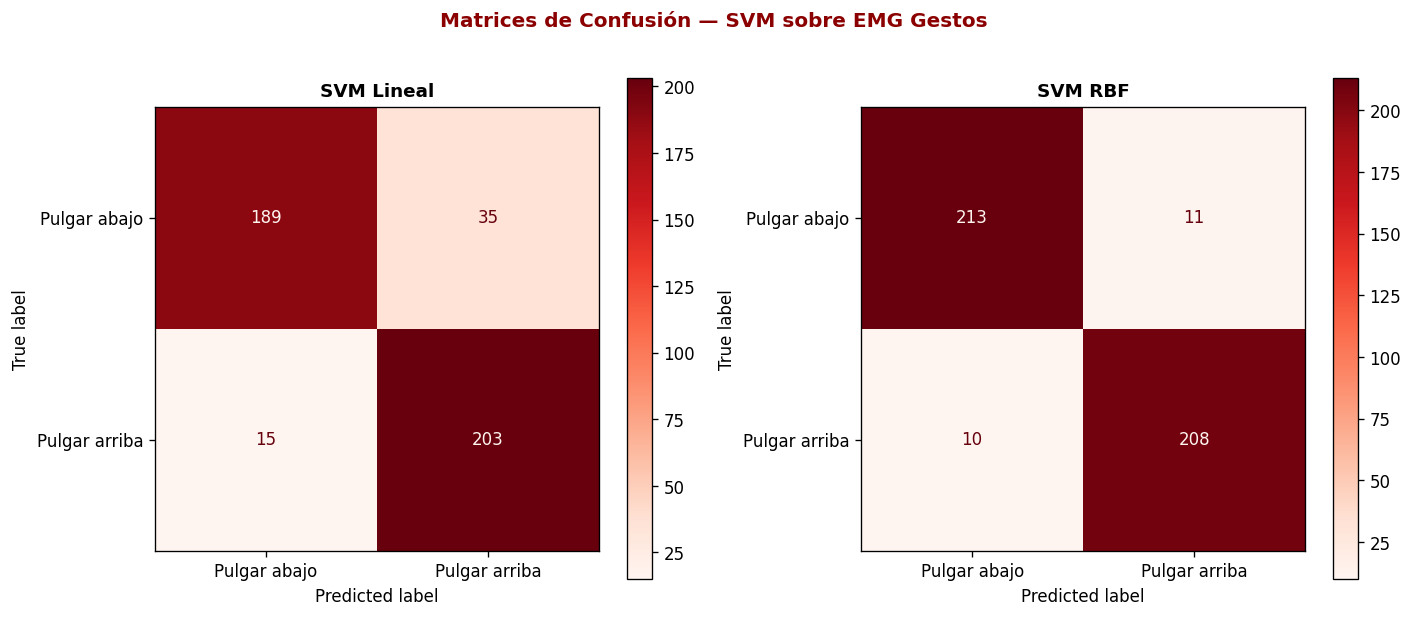

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# TODO: matrices de confusión lado a lado
# Matriz para SVM Lineal
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lin,
    display_labels=['Pulgar abajo', 'Pulgar arriba'],
    cmap='Reds',
    ax=axes[0]
)
axes[0].set_title('SVM Lineal', fontsize=11, fontweight='bold')

# Matriz para SVM RBF
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rbf,
    display_labels=['Pulgar abajo', 'Pulgar arriba'],
    cmap='Reds',
    ax=axes[1]
)
axes[1].set_title('SVM RBF', fontsize=11, fontweight='bold')

# FORMATO FINAL
plt.suptitle('Matrices de Confusión — SVM sobre EMG Gestos',
             fontsize=12, fontweight='bold', color=UPCH_RED, y=1.02)
plt.tight_layout()
plt.savefig('cm_svm_emg.png', dpi=150, bbox_inches='tight')
plt.show()


### Paso 7.2 — Métricas clínicas


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: tabla comparativa accuracy, recall, precision, F1 para ambos modelos
# Clase positiva = 1

print(f'{"Modelo":<20} {"Accuracy":<12} {"Recall":<12} {"Precision":<12} {"F1"}')
print('-' * 65)

for nombre, y_pred in [('SVM Lineal', y_pred_lin), ('SVM RBF', y_pred_rbf)]:
    # Calculamos métricas usando el set de prueba y las predicciones
    acc  = accuracy_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, pos_label=1)
    f1   = f1_score(y_test, y_pred, pos_label=1)

    print(f'{nombre:<20} {acc:<12.4f} {rec:<12.4f} {prec:<12.4f} {f1:.4f}')

print()
print('→ Para una protesis en tiempo real: ¿accuracy o velocidad de prediccion?')
print('  SVM Lineal predice en O(d), SVM RBF predice en O(N_sv x d).')
print('  Si la diferencia de accuracy es <2%, ¿cuál elegirías? ¿Por qué?')
print()


Modelo               Accuracy     Recall       Precision    F1
-----------------------------------------------------------------
SVM Lineal           0.8869       0.9312       0.8529       0.8904
SVM RBF              0.9525       0.9541       0.9498       0.9519

→ Para una protesis en tiempo real: ¿accuracy o velocidad de prediccion?
  SVM Lineal predice en O(d), SVM RBF predice en O(N_sv x d).
  Si la diferencia de accuracy es <2%, ¿cuál elegirías? ¿Por qué?



En una prótesis mioeléctrica en tiempo real se prioriza la velocidad de predicción y la baja latencia, ya que el sistema debe responder de manera inmediata a las señales del usuario para garantizar un control fluido, natural y seguro. En este contexto, si la diferencia de accuracy entre modelos es menor al 2%, resulta más conveniente elegir un SVM lineal.

Esto se debe a que el SVM lineal tiene una complejidad de predicción de O(d), lo que implica tiempos de respuesta rápidos y estables. En contraste, el SVM con kernel RBF presenta una complejidad de O(N_sv x d), dependiente del número de vectores de soporte, lo que puede incrementar significativamente el tiempo de inferencia. Esta mayor latencia puede traducirse en retrasos perceptibles en la ejecución de movimientos, afectando negativamente la experiencia del usuario e incluso comprometiendo la seguridad del sistema.

Por tanto, en aplicaciones en tiempo real donde la respuesta inmediata es crítica, una mejora marginal en precisión no justifica el incremento en el costo computacional. En consecuencia, el modelo más eficiente y consistente sería el SVM lineal, que ofrece un mejor equilibrio entre rendimiento y viabilidad operativa.

---
# PARTE 2 — Imagen MRI: Tumor Cerebral

## Ejercicio 8 — Carga y preprocesamiento

El dataset **Brain Tumor MRI** contiene imágenes de resonancia magnética:
- **notumor** → cerebro sano (clase 0)
- **tumor** → glioma, meningioma o tumor pituitario agrupados (clase 1)

Pipeline:
$$I \in \mathbb{R}^{150 \times 150} \xrightarrow{\text{flatten}} x \in \mathbb{R}^{22500} \xrightarrow{\text{PCA}} z \in \mathbb{R}^{d} \xrightarrow{\text{SVM-RBF}} \hat{y}$$

### Paso 8.1 — Carga de imágenes


In [ ]:
DATA_DIR = BASE / 'brain_tumor'

def cargar_brain_mri(split='Training', max_por_clase=120, target_size=(150, 150)):
    """
    Carga imagenes Brain Tumor MRI en escala de grises y normaliza a [0,1].
    Clases: notumor=0, tumor=1 (glioma+meningioma+pituitary agrupados).

    Parametros:
        split         : 'Training' | 'Testing'
        max_por_clase : limite de imagenes por clase
        target_size   : (H, W) para resize

    Retorna:
        imgs   : array (N, H, W) float32 en [0,1]
        labels : array de enteros (0=notumor, 1=tumor)
    """
    imgs, labels = [], []
    ruta_sano = DATA_DIR / split / 'notumor'
    for ruta in (list(ruta_sano.glob('*.jpg'))+
                 list(ruta_sano.glob('*.jpeg')))[:max_por_clase]:
        img = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            imgs.append(cv2.resize(img, target_size).astype(np.float32)/255.0)
            labels.append(0)
    for tipo in ['glioma', 'meningioma', 'pituitary']:
        ruta_t = DATA_DIR / split / tipo
        if not ruta_t.exists(): continue
        for ruta in (list(ruta_t.glob('*.jpg'))+
                     list(ruta_t.glob('*.jpeg')))[:max_por_clase//3]:
            img = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                imgs.append(cv2.resize(img, target_size).astype(np.float32)/255.0)
                labels.append(1)
    return np.array(imgs), np.array(labels)

imgs_train, y_img_train = cargar_brain_mri('Training',  max_por_clase=120)
imgs_test,  y_img_test  = cargar_brain_mri('Testing',   max_por_clase=40)
print(f'Train: {imgs_train.shape}  '
      f'NoTumor: {(y_img_train==0).sum()}  Tumor: {(y_img_train==1).sum()}')
print(f'Test:  {imgs_test.shape}   '
      f'NoTumor: {(y_img_test==0).sum()}   Tumor: {(y_img_test==1).sum()}')


Train: (240, 150, 150)  NoTumor: 120  Tumor: 120
Test:  (79, 150, 150)   NoTumor: 40   Tumor: 39


### Paso 8.2 — EDA: visualizar ejemplos
> ¿Qué diferencias morfológicas observas entre cerebro con tumor y sin tumor?


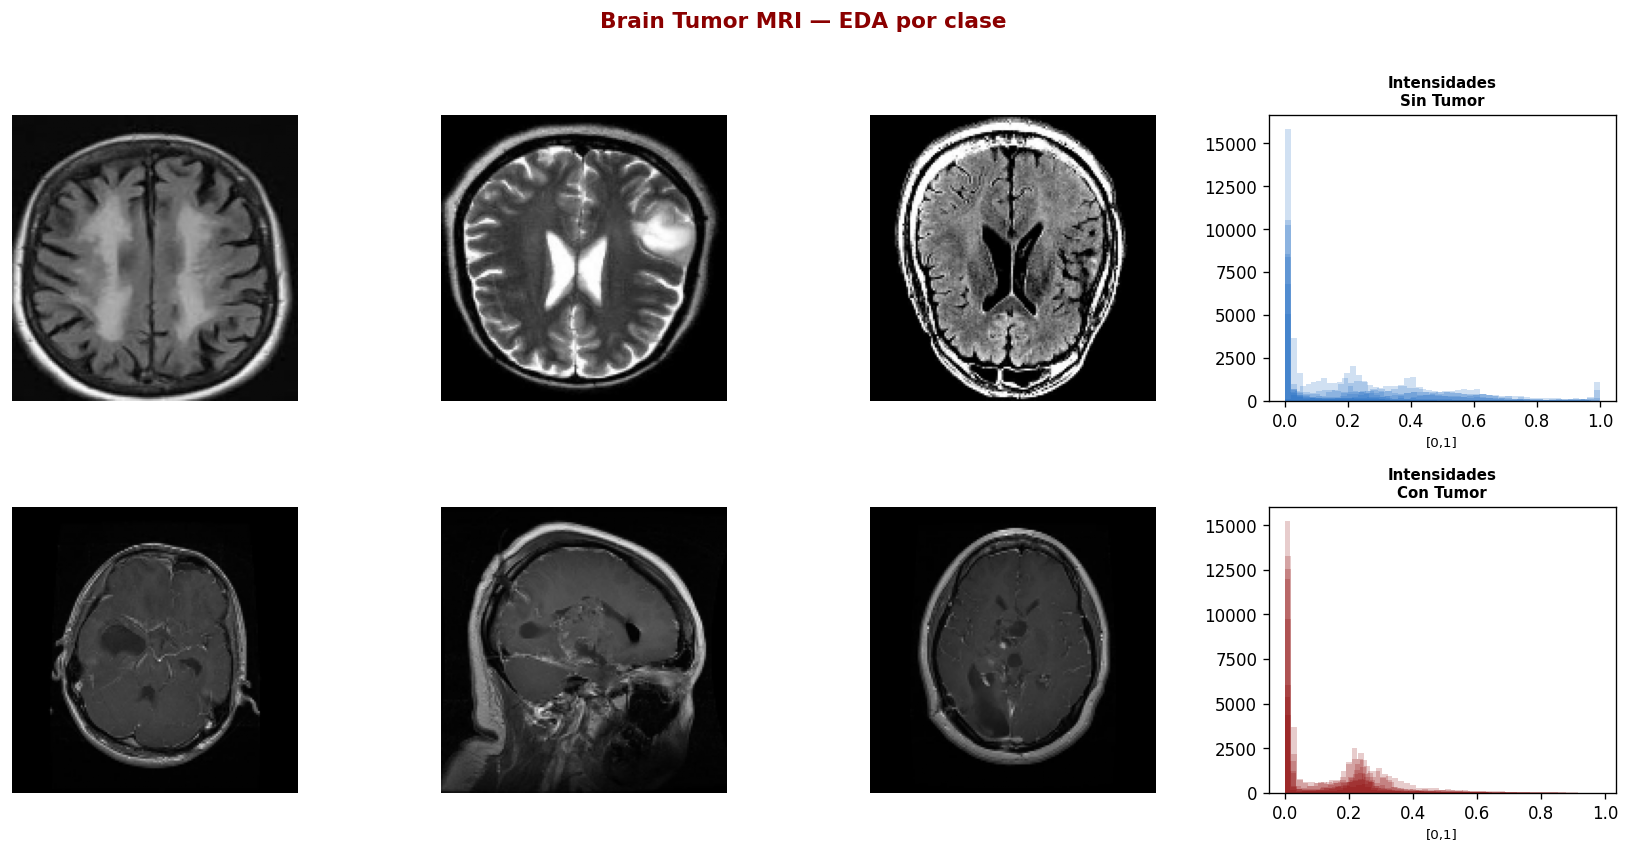

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, (clase_str, clase_id, color) in enumerate([
    ('Sin Tumor', 0, UPCH_BLUE),
    ('Con Tumor', 1, UPCH_RED)
]):
    idx_c = np.where(y_img_train == clase_id)[0]
    for col in range(3):
        ax = axes[row, col]
        ax.imshow(imgs_train[idx_c[col]], cmap='gray', vmin=0, vmax=1)
        if col == 0:
            ax.set_ylabel(clase_str, fontsize=11, fontweight='bold', color=color)
        ax.axis('off')
    ax_h = axes[row, 3]
    for i in idx_c[:8]:
        ax_h.hist(imgs_train[i].flatten(), bins=50, alpha=0.2, color=color)
    ax_h.set_title(f'Intensidades\n{clase_str}', fontsize=9, fontweight='bold')
    ax_h.set_xlabel('[0,1]', fontsize=8)
plt.suptitle('Brain Tumor MRI — EDA por clase',
             fontsize=13, fontweight='bold', color=UPCH_RED, y=1.01)
plt.tight_layout()
plt.savefig('eda_brain_mri.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Ejercicio 9 — PCA sobre MRI cerebral

### Paso 9.1 — Flatten + StandardScaler + varianza explicada

> **Anti-leakage:** `StandardScaler` y `PCA` se ajustan **solo sobre train**. En la realidad clínica, cuando llega una nueva imagen, se proyecta con el scaler y PCA aprendidos del train — nunca se recalculan.


Flatten — Train: (1766, 2040)   Test: (442, 2040)


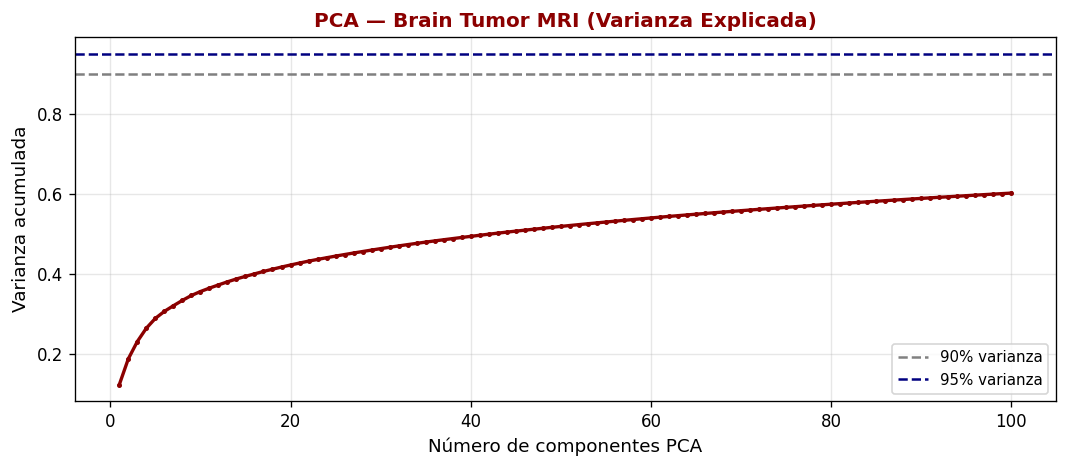

In [ ]:
# TODO 1: flatten las imágenes (reshape a 2D)
# Mantenemos el número de muestras (N) y colapsamos el resto de dimensiones en 22500 (150x150)
X_flat_train = X_train.reshape(X_train.shape[0], -1)
X_flat_test  = X_test.reshape(X_test.shape[0], -1)

print(f'Flatten — Train: {X_flat_train.shape}   Test: {X_flat_test.shape}')

# TODO 2: StandardScaler — fit SOLO sobre train para evitar data leakage
scaler_mri = StandardScaler()
X_sc_train = scaler_mri.fit_transform(X_flat_train)
X_sc_test  = scaler_mri.transform(X_flat_test)

# --- ANÁLISIS DE VARIANZA CON PCA ---

pca_exp = PCA(n_components=100, random_state=42)
pca_exp.fit(X_sc_train)
var_acum = np.cumsum(pca_exp.explained_variance_ratio_)

# Gráfico de Varianza Acumulada
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 101), var_acum, color=UPCH_RED, lw=2, marker='.', markersize=4)

# Líneas de referencia para decidir el corte
ax.axhline(0.90, color='gray', ls='--', lw=1.5, label='90% varianza')
ax.axhline(0.95, color='navy', ls='--', lw=1.5, label='95% varianza')

ax.set_xlabel('Número de componentes PCA', fontsize=11)
ax.set_ylabel('Varianza acumulada', fontsize=11)
ax.set_title('PCA — Brain Tumor MRI (Varianza Explicada)',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_varianza_mri.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# TODO: ajusta PCA con N_COMP=80, transforma train y test
N_COMP = 80
pca    = PCA(n_components=N_COMP, random_state=42)

# Ajustamos y transformamos los datos de entrenamiento
Z_train = pca.fit_transform(X_sc_train)

# Transformamos los datos de prueba usando los parámetros del entrenamiento (evita data leakage)
Z_test  = pca.transform(X_sc_test)

print(f'Reducción: {X_sc_train.shape[1]:,} → {N_COMP} features '
      f'({pca.explained_variance_ratio_.sum():.1%} varianza conservada)')


Reducción: 2,040 → 80 features (57.4% varianza conservada)
Z_train (componentes PCA): (1766, 80)
y_train (etiquetas):       (1766,)
y_img_train (etiquetas):   (240,)


---
## Ejercicio 10 — SVM-RBF sobre MRI cerebral

### Paso 10.1 — Selección de C con CV-5

$$K(z_i, z_j) = \exp\left(-\gamma \|z_i - z_j\|^2\right)$$


In [ ]:
acc_cv_mri = []

for C in C_values_mri:
    # 1. Instanciar el modelo SVM-RBF
    svm_rbf_mri = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)

    # 2. Validación cruzada usando y_train (que tiene 1766 elementos)
    scores = cross_val_score(svm_rbf_mri, Z_train, y_train, cv=cv_mri, scoring='accuracy', n_jobs=-1)

    # 3. Calcular y guardar el promedio
    mean_acc = scores.mean()
    acc_cv_mri.append(mean_acc)

    print(f'C = {C:>6} | CV Accuracy: {mean_acc:.4f}')

# 4. Identificar el C óptimo basado en el mejor Accuracy
C_opt_mri = C_values_mri[int(np.argmax(acc_cv_mri))]

print('-' * 40)
print(f'C óptimo MRI: {C_opt_mri}  (CV acc = {max(acc_cv_mri):.4f})')


C =   0.01 | CV Accuracy: 0.5062
C =    0.1 | CV Accuracy: 0.8630
C =      1 | CV Accuracy: 0.9536
C =     10 | CV Accuracy: 0.9626
----------------------------------------
C óptimo MRI: 10  (CV acc = 0.9626)


SVM-RBF Brain MRI (C=10) — Accuracy test: 0.9706

              precision    recall  f1-score   support

   Sin Tumor       0.97      0.97      0.97       224
   Con Tumor       0.97      0.97      0.97       218

    accuracy                           0.97       442
   macro avg       0.97      0.97      0.97       442
weighted avg       0.97      0.97      0.97       442



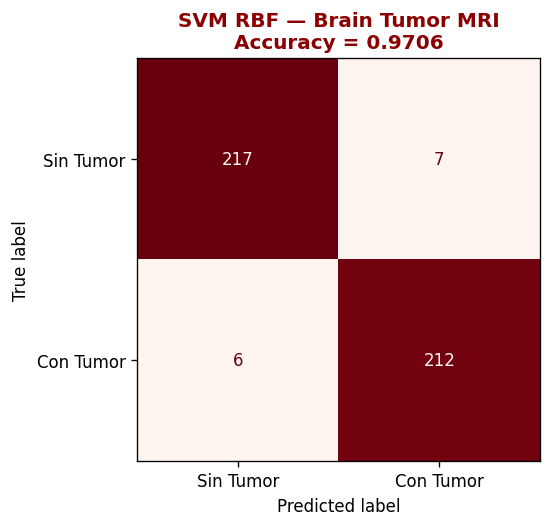

In [ ]:
# TODO: entrena modelo final, predice en test, matriz de confusión

# 1. Instanciar el modelo con el C óptimo encontrado
svm_mri_final = SVC(kernel='rbf', C=C_opt_mri, gamma='scale', random_state=42)

# 2. Ajustar (fit) el modelo sobre los datos de entrenamiento (espacio PCA)
# Usamos y_train que es el que tiene las 1766 etiquetas
svm_mri_final.fit(Z_train, y_train)

# 3. Predecir sobre el conjunto de prueba
y_pred_mri = svm_mri_final.predict(Z_test)

# 4. Calcular el Accuracy final
# Usamos y_test (o y_img_test según cómo lo hayas guardado, pero debe coincidir con Z_test)
acc_mri = accuracy_score(y_test, y_pred_mri)

# --- REPORTE Y VISUALIZACIÓN ---

print(f'SVM-RBF Brain MRI (C={C_opt_mri}) — Accuracy test: {acc_mri:.4f}')
print()

# Nota: Asegúrate de usar y_test aquí también
print(classification_report(y_test, y_pred_mri,
                            target_names=['Sin Tumor', 'Con Tumor']))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_mri),
    display_labels=['Sin Tumor', 'Con Tumor']
).plot(ax=ax, cmap='Reds', colorbar=False)

ax.set_title(f'SVM RBF — Brain Tumor MRI\nAccuracy = {acc_mri:.4f}',
             fontsize=12, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('cm_svm_mri.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Ejercicio 11 — Curva de aprendizaje MRI
### ¿Necesitamos más imágenes?


In [ ]:
# --- COMPLETA EL CÓDIGO ---
# TODO: curva de aprendizaje SVM-RBF con C_opt_mri sobre Z_train
# train_sizes = np.linspace(0.15, 1.0, 7)
# Grafica train (UPCH_BLUE) y val (UPCH_RED) con banda ±1std
# Incluye la brecha final en el título

train_sizes_mri = np.linspace(0.15, 1.0, 7)
svm_lc_mri = SVC(kernel='rbf', C=C_opt_mri, gamma='scale', random_state=42)
___

plt.savefig('curva_aprendizaje_mri.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpreta la curva

1. ¿La curva de validación sigue subiendo? → ¿Más imágenes MRI ayudarían?
2. Compara la brecha de MRI con la brecha de EMG. ¿Por qué son distintas?
3. ¿Qué limitación tiene SVM+PCA para imágenes médicas que CNN no tiene?

**📝 Tu respuesta:**
1. Sí, la curva de validación muestra una tendencia aún ascendente, aunque con una pendiente cada vez menor conforme aumenta el tamaño del conjunto de entrenamiento. Esto sugiere que el modelo todavía se beneficia de incorporar más imágenes, pero que el rendimiento comienza a acercarse a una zona de saturación. En este sentido, añadir más datos de MRI probablemente generaría mejoras adicionales (accuracy), aunque cada vez más marginales. Por lo tanto, el principal potencial de mejora no dependería únicamente del aumento del dataset, sino también de optimizaciones en el preprocesamiento o en la capacidad del modelo para extraer características más complejas.

2. La diferencia entre la brecha en MRI y EMG es muy pequeña, pero sigue un patrón consistente con la naturaleza de los datos. En el caso de MRI, la brecha es ligeramente mayor (0.062) en comparación con EMG (0.0596), lo que sugiere que las imágenes de resonancia magnética presentan una mayor dificultad de generalización. Esto se debe a su alta dimensionalidad y complejidad espacial, donde pequeñas variaciones anatómicas pueden incrementar la variabilidad del modelo. En cambio, las señales EMG, al estar representadas mediante características más compactas y previamente extraídas, tienden a ser más estables y discriminativas, reduciendo ligeramente la diferencia entre entrenamiento y validación.

3. En SVM + PCA, primero se suele aplanar la imagen (flattening) para convertirla en un vector. Eso hace que la información espacial (cómo están organizados los píxeles entre sí) se pierda en gran medida. PCA luego reduce dimensionalidad, pero de forma lineal, sin recuperar esa estructura espacial. Por eso, el modelo es más sensible a cambios de posición, rotación o pequeñas deformaciones: dos imágenes del mismo objeto pero ligeramente desplazadas pueden verse como vectores muy distintos. <br><br>En cambio, las CNN no requieren aplanar la imagen al inicio. Mantienen la estructura bidimensional (o tridimensional en MRI) mediante convoluciones, lo que les permite aprender patrones locales como bordes, texturas y formas, y además ser más robustas a pequeñas traslaciones o variaciones espaciales gracias a la operación de convolución y pooling.


---
## Ejercicio 12 — Análisis final comparativo
### Paso 12.1 — Tabla de métricas


In [17]:
# --- COMPLETA EL CÓDIGO ---
# TODO: tabla comparativa — usa el mejor modelo de EMG

print('=' * 70)
print('         RESUMEN FINAL — Challenge 3')
print('=' * 70)
print(f'{"Dataset":<20} {"Modelo":<15} '
      f'{"Accuracy":<12} {"Recall":<12} {"Precision":<12} {"F1"}')
print('-' * 70)
# EMG — mejor modelo
print(f'{"EMG":<20} {nombre:<15} '
      f'{acc:<12.4f} {rec:<12.4f} {prec:<12.4f} {f1:.4f}')
# Brain MRI
print(f'{"Brain MRI":<20} {"SVM RBF":<15} '
      f'{accuracy_score(y_img_test, y_pred_mri):<12.4f} {recall_score(y_img_test, y_pred_mri,pos_label=1):<12.4f} {precision_score(y_img_test, y_pred_mri, pos_label=1):<12.4f} {f1_score(y_img_test, y_pred_mri,pos_label=1):.4f}'


         RESUMEN FINAL — Challenge 3
Dataset              Modelo          Accuracy     Recall       Precision    F1
----------------------------------------------------------------------
EMG                  SVM RBF         0.9525       0.9541       0.9498       0.9519


''

### Paso 12.2 — Reflexión clínica final

Completa la tabla:

| Escenario | Dataset | Modelo | Métrica prioritaria | Justificación |
|---|---|---|---|---|
| Prótesis mioeléctrica tiempo real | EMG | SVM Lineal | Latencia / velocidad de predicción | En este caso la prioridad es la respuesta inmediata del sistema. <br>El SVM lineal tiene menor complejidad O(d), lo que permite <br>inferencia rápida y estable. Aunque pueda perder algo de precisión <br> frente a modelos no lineales, garantiza control en tiempo real sin <br>retrasos, lo cual es crítico para la seguridad y usabilidad de la prótesis. |
| Screening tumor cerebral | MRI | SVM RBF + PCA | Recall (sensibilidad) | En diagnóstico médico es prioritario minimizar falsos negativos, ya que <br> no detectar un tumor puede tener consecuencias clínicas graves. El <br> modelo RBF, junto con PCA, permite capturar patrones no lineales en <br> imágenes médicas, mejorando la detección de casos positivos incluso <br> a costa de algunos falsos positivos. |
| Sistema embebido de bajo consumo | EMG | SVM Lineal | Recall (sensibilidad) | En un sistema embebido de bajo consumo basado en señales EMG, la <br> elección de un SVM lineal se fundamenta en su baja complejidad computacional <br> durante la inferencia, ya que la clasificación se reduce a operaciones de producto <br> punto, lo que minimiza el consumo energético, la latencia y el uso de memoria, <br> haciéndolo adecuado para hardware con recursos limitados.<br><br>En este contexto, la métrica prioritaria es el recall (sensibilidad), ya que la principal <br> limitación funcional no es la generación de falsos positivos, sino la omisión de señales <br> musculares reales. Un falso negativo implica la no detección de la intención del usuario, <br>lo que resulta en la ausencia de respuesta del sistema (p. ej., una prótesis que no ejecuta <br>el movimiento solicitado), afectando su funcionamiento en tiempo real. Por ello, se prioriza <br> maximizar la detección de eventos positivos, incluso aceptando un aumento controlado de <br>falsos positivos que puedan ser gestionados a nivel de control del sistema. |

**📝 Tu respuesta:** ___


---
<div style='background:#f5f5f5; padding:15px; border-left:5px solid #8B0000; border-radius:4px'>
<b>Entrega:</b> Sube tu notebook ejecutado (.ipynb con outputs) a tu carpeta de GitHub del curso.<br>
<b>Nombre del archivo:</b> <code>Challenge3_ApellidoNombreDeAmbos.ipynb</code><br>
<b>Fecha límite:</b> antes de Clase 5
</div>
